In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df = pd.read_csv("WaterQuality_Dataset.csv")
df.head()

,Country,Year,State,Station_ID,River_Location,River_Name,Monitoring_Month,"Minimum Temperature For River Water (UOM:Â°C(Centigrade)), Scaling Factor:1","Maximum Temperature For River Water (UOM:Â°C(Centigrade)), Scaling Factor:1","Minimum Value Of Dissolved Oxygen (UOM:mg/L(Milligramsperliter)), Scaling Factor:1",...,"Minimum Biochemical Oxygen Demand (Bod) (UOM:mg/L(Milligramsperliter)), Scaling Factor:1","Maximum Biochemical Oxygen Demand (Bod) (UOM:mg/L(Milligramsperliter)), Scaling Factor:1","Minimum Of Nitrate (N) Required For River Water (UOM:mg/L(Milligramsperliter)), Scaling Factor:1","Maximum Of Nitrate (N) Required For River Water (UOM:mg/L(Milligramsperliter)), Scaling Factor:1","Minimum Of Fecal Coliforms Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1","Maximum Of Fecal Coliforms Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1","Minimum Total Coliform Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1","Minimum Total Coliform Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1.1","Minimum Fecal Streptococci Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1","Maximum Fecal Streptococci Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1"
0,India,2023,Madhya Pradesh,4620,"RIVER AJAB BOURALI AT PETLAWAD DAM PETLAVAD, J...",Ajab,Oct,20.0,21.5,6.9,...,1.0,1.2,NaN,1.69,2.0,2.0,21.0,120.0,2.0,2.0
1,India,2023,Tamil Nadu,3023,"RIVER VASISTA AT THULUKANNUR AT SALEM, D/S OF ...",Vasista,Aug,26.0,31.0,0.3,...,2.7,120.0,0.32,4.43,9.0,390000.0,64.0,240.0,2.0,3.0
2,India,2023,Meghalaya,3368,RIVER NONBAH AT PHOTSOHSAT,Nonbah,Apr,13.6,20.0,6.6,...,1.1,NaN,0.32,0.54,4.0,70.0,93.0,460.0,2.0,3.0
3,India,2023,Karnataka,3578,RIVER CAUVERY D/S OF MADDUR WATER SUPPLY TREAT...,Cauvery,Apr,19.0,27.0,6.5,...,1.0,3.0,0.75,2.40,68.0,110.0,75.0,150.0,2.0,3.0
4,India,2023,Tripura,3419,"RIVER MANU AT KUMARGHAT, NORTH TRIPURA",Manu,Jan,21.0,31.0,5.3,...,1.2,1.9,0.70,1.70,31.0,58.0,150.0,240.0,2.0,3.0


In [61]:
df.columns = df.columns.str.strip()

df.drop(columns=[
    'Minimum Total Coliform Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1',
    'Minimum Total Coliform Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1.1',
    'Minimum Fecal Streptococci Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1',
    'Maximum Fecal Streptococci Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1',
    'Minimum Of Fecal Coliforms Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1',
    'Maximum Of Fecal Coliforms Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1'
], inplace=True)

In [62]:
df.rename(columns={
    'State Name ': 'State',
    'Monitoring Location': 'Location',
    'Minimum Value Of Dissolved Oxygen (UOM:mg/L(Milligramsperliter)), Scaling Factor:1': 'Min_Dissolved_Oxygen',
    'Maximum Value Of Dissolved Oxygen (UOM:mg/L(Milligramsperliter)), Scaling Factor:1': 'Max_Dissolved_Oxygen',
    'Minimum Potential Of Hydrogen Value In River Water (UOM:pH), Scaling Factor:1': 'Min_pH',
    'Maximum Potential Of Hydrogen Value In River Water (UOM:pH), Scaling Factor:1': 'Max_pH',
    'Minimum Biochemical Oxygen Demand (Bod) (UOM:mg/L(Milligramsperliter)), Scaling Factor:1': 'Min_BOD',
    'Maximum Biochemical Oxygen Demand (Bod) (UOM:mg/L(Milligramsperliter)), Scaling Factor:1': 'Max_BOD',
    'Maximum Of Nitrate (N) Required For River Water (UOM:mg/L(Milligramsperliter)), Scaling Factor:1' : 'Max_Nitrate (N) Required For River Water',
    'Minimum Of Fecal Coliforms Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1' : 'Min_Fecal Coliforms Required For River Water',
    'Maximum Of Fecal Coliforms Required For River Water (UOM:MPN/100ml(MostprobableNumberper100mililiters)), Scaling Factor:1' : 'Max_Fecal Coliforms Required For River Water',
    'Minimum Of Nitrate (N) Required For River Water (UOM:mg/L(Milligramsperliter)), Scaling Factor:1' : 'Min_Nitrate (N) Required For River Water',
    'Minimum Conductivity Level (UOM:Âµmho/cm(micromhospercentimeter)), Scaling Factor:1' : 'Min_Conductivity_Level',
    'Maximum Conductivity Level (UOM:Âµmho/cm(micromhospercentimeter)), Scaling Factor:1' : 'Max_Conductivity_Level',
    'Minimum Temperature For River Water (UOM:Â°C(Centigrade)), Scaling Factor:1' : 'Min_Temp For River Water',
    'Maximum Temperature For River Water (UOM:Â°C(Centigrade)), Scaling Factor:1' : 'Max_Temp For River Water'
}, inplace=True)
df

,Country,Year,State,Station_ID,River_Location,River_Name,Monitoring_Month,Min_Temp For River Water,Max_Temp For River Water,Min_Dissolved_Oxygen,Max_Dissolved_Oxygen,Min_pH,Max_pH,Min_Conductivity_Level,Max_Conductivity_Level,Min_BOD,Max_BOD,Min_Nitrate (N) Required For River Water,Max_Nitrate (N) Required For River Water
0,India,2023,Madhya Pradesh,4620,"RIVER AJAB BOURALI AT PETLAWAD DAM PETLAVAD, J...",Ajab,Oct,20.0,21.5,6.9,7.7,7.5,8.3,300.0,539.0,1.0,1.2,NaN,1.69
1,India,2023,Tamil Nadu,3023,"RIVER VASISTA AT THULUKANNUR AT SALEM, D/S OF ...",Vasista,Aug,26.0,31.0,0.3,6.0,6.9,8.0,878.0,2350.0,2.7,120.0,0.32,4.43
2,India,2023,Meghalaya,3368,RIVER NONBAH AT PHOTSOHSAT,Nonbah,Apr,13.6,20.0,6.6,8.6,6.7,7.3,31.0,44.0,1.1,NaN,0.32,0.54
3,India,2023,Karnataka,3578,RIVER CAUVERY D/S OF MADDUR WATER SUPPLY TREAT...,Cauvery,Apr,19.0,27.0,6.5,7.3,8.0,8.7,218.0,481.0,1.0,3.0,0.75,2.40
4,India,2023,Tripura,3419,"RIVER MANU AT KUMARGHAT, NORTH TRIPURA",Manu,Jan,21.0,31.0,5.3,6.4,7.1,7.7,8542.0,179.0,1.2,1.9,0.70,1.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1637,India,2023,Odisha,3893,RIVER KATHAJODI AT CUTTACK FD/S AT KAMASASAN,Kathajodi,Jul,22.0,32.0,6.6,8.5,7.3,8.5,158.0,327.0,1.3,2.5,0.32,0.98
1638,India,2023,Tamil Nadu,1205,"RIVER BHAVANI AT BHAVANI, TAMILNADU",Bhavani,Jan,28.7,37.0,5.3,6.7,7.6,NaN,342.0,968.0,1.0,2.4,0.32,3.92
1639,India,2023,Maharashtra,1209,"RIVER GODAVARI AT RAHER, VILLAGE.RAHER, TALUKA...",Godavari,Jan,18.0,34.0,5.5,7.2,8.1,8.7,376.0,7952.0,2.6,6.5,0.31,4.32
1640,India,2023,Uttar Pradesh,1350,"RIVER GOMTI AT SITAPUR U/S DADNAMAU GHAT, U.P.",Gomti,Nov,NaN,NaN,6.4,12.2,7.8,NaN,238.0,422.0,2.0,4.4,0.00,1.62


In [63]:
print("~ Data Overview: Info and Descriptive Statistics ~")
df.info()
df.describe()

~ Data Overview: Info and Descriptive Statistics ~
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1642 entries, 0 to 1641
Data columns (total 19 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   1642 non-null   object 
 1   Year                                      1642 non-null   int64  
 2   State                                     1642 non-null   object 
 3   Station_ID                                1642 non-null   int64  
 4   River_Location                            1642 non-null   object 
 5   River_Name                                1642 non-null   object 
 6   Monitoring_Month                          1642 non-null   object 
 7   Min_Temp For River Water                  1606 non-null   float64
 8   Max_Temp For River Water                  1607 non-null   float64
 9   Min_Dissolved_Oxygen                      1641 non-null 

,Year,Station_ID,Min_Temp For River Water,Max_Temp For River Water,Min_Dissolved_Oxygen,Max_Dissolved_Oxygen,Min_pH,Max_pH,Min_Conductivity_Level,Max_Conductivity_Level,Min_BOD,Max_BOD,Min_Nitrate (N) Required For River Water,Max_Nitrate (N) Required For River Water
count,1642.0,1642.000000,1606.000000,1607.000000,1641.000000,1641.000000,1536.000000,1543.000000,1585.000000,1585.000000,1527.00000,1539.000000,1535.000000,1531.00000
mean,2023.0,4528.786845,18.468306,27.862228,5.808714,7.893723,7.194544,8.080544,326.702839,1224.195584,2.32482,5.836582,0.726860,4.47759
std,0.0,5957.054521,5.536722,6.186615,1.980867,1.906700,0.590398,0.542945,1008.261599,4137.833435,4.01688,13.895300,2.135866,25.18340
min,2023.0,1.000000,2.000000,4.000000,0.300000,0.300000,2.000000,3.000000,5.000000,31.000000,1.00000,1.000000,0.000000,0.00000
25%,2023.0,1822.250000,15.000000,24.150000,5.100000,7.000000,7.000000,7.800000,128.000000,279.000000,1.00000,1.900000,0.300000,0.54000
50%,2023.0,2954.500000,19.000000,29.000000,6.200000,7.900000,7.200000,8.200000,210.000000,468.000000,1.20000,2.600000,0.320000,1.36000
75%,2023.0,4427.750000,22.000000,31.650000,7.000000,9.000000,7.500000,8.400000,326.000000,813.000000,2.10000,3.900000,0.600000,3.07000
max,2023.0,30089.000000,29.000000,89.900000,11.400000,14.100000,9.000000,9.900000,34400.000000,54200.000000,48.00000,294.000000,32.000000,790.02000


In [64]:
df.isnull().sum()

Country                                       0
Year                                          0
State                                         0
Station_ID                                    0
River_Location                                0
River_Name                                    0
Monitoring_Month                              0
Min_Temp For River Water                     36
Max_Temp For River Water                     35
Min_Dissolved_Oxygen                          1
Max_Dissolved_Oxygen                          1
Min_pH                                      106
Max_pH                                       99
Min_Conductivity_Level                       57
Max_Conductivity_Level                       57
Min_BOD                                     115
Max_BOD                                     103
Min_Nitrate (N) Required For River Water    107
Max_Nitrate (N) Required For River Water    111
dtype: int64

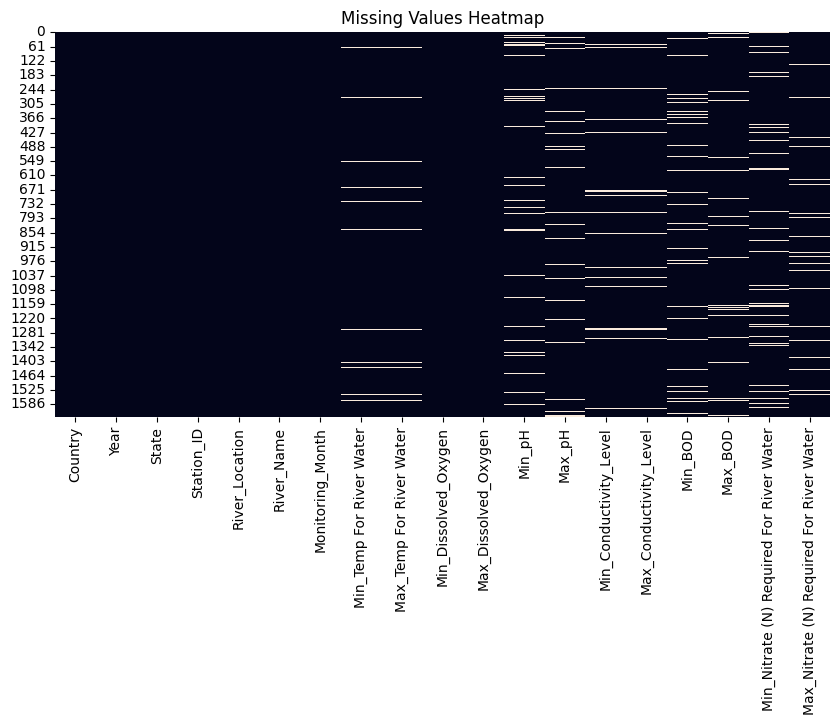

In [65]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [66]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [67]:
df.isnull().sum()

Country                                     0
Year                                        0
State                                       0
Station_ID                                  0
River_Location                              0
River_Name                                  0
Monitoring_Month                            0
Min_Temp For River Water                    0
Max_Temp For River Water                    0
Min_Dissolved_Oxygen                        0
Max_Dissolved_Oxygen                        0
Min_pH                                      0
Max_pH                                      0
Min_Conductivity_Level                      0
Max_Conductivity_Level                      0
Min_BOD                                     0
Max_BOD                                     0
Min_Nitrate (N) Required For River Water    0
Max_Nitrate (N) Required For River Water    0
dtype: int64

In [68]:
df.drop_duplicates(inplace=True)

In [69]:
# removing leading/trailing whitespace
df['State'] = df['State'].str.strip()
df['River_Location'] = df['River_Location'].str.strip()

In [70]:
print("Top 10 states with the highest average maximum nitrate (N) levels in river water, highlighting areas with potential water quality concerns related to nitrates.")
df.groupby('State')['Max_Nitrate (N) Required For River Water'].mean().sort_values(ascending=False).head(10)

Top 10 states with the highest average maximum nitrate (N) levels in river water, highlighting areas with potential water quality concerns related to nitrates.


State
Telangana         18.847861
Manipur           12.039799
Madhya Pradesh     8.007396
Karnataka          7.531304
Odisha             7.191167
Tamil Nadu         6.790357
Sikkim             5.916256
Uttar Pradesh      5.881004
Mizoram            3.899134
Rajasthan          3.799362
Name: Max_Nitrate (N) Required For River Water, dtype: float64

In [71]:
df['Avg_Dissolved_Oxygen'] = (df['Min_Dissolved_Oxygen'] + df['Max_Dissolved_Oxygen']) / 2
df['Avg_BOD'] = (df['Min_BOD'] + df['Max_BOD']) / 2   #Biochemical Oxygen Demand
df['Avg_pH'] = (df['Min_pH'] + df['Max_pH']) / 2
df['Avg_Temp'] = (df['Min_Temp For River Water'] + df['Max_Temp For River Water']) / 2

In [72]:
df[['Avg_Dissolved_Oxygen', 'Avg_BOD', 'Avg_pH']].describe()

,Avg_Dissolved_Oxygen,Avg_BOD,Avg_pH
count,1613.000000,1613.000000,1613.000000
mean,6.848699,4.103375,7.636298
std,1.760472,7.969889,0.496012
min,0.300000,1.000000,2.800000
25%,6.050000,1.550000,7.450000
50%,7.250000,2.150000,7.700000
75%,7.900000,3.418291,7.900000
max,11.400000,147.500000,8.750000


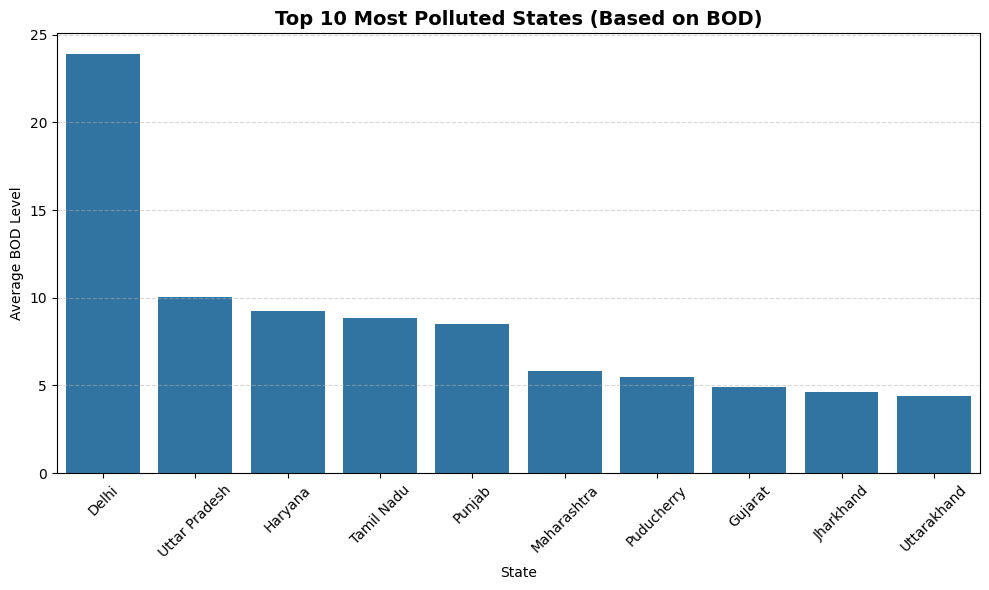

In [73]:
plt.figure(figsize=(10,6))
top_states = df.groupby('State')['Avg_BOD'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_states.index, y=top_states.values)

plt.title("Top 10 Most Polluted States (Based on BOD)", fontsize=14, weight='bold')
plt.xlabel("State")
plt.ylabel("Average BOD Level")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of Average pH')

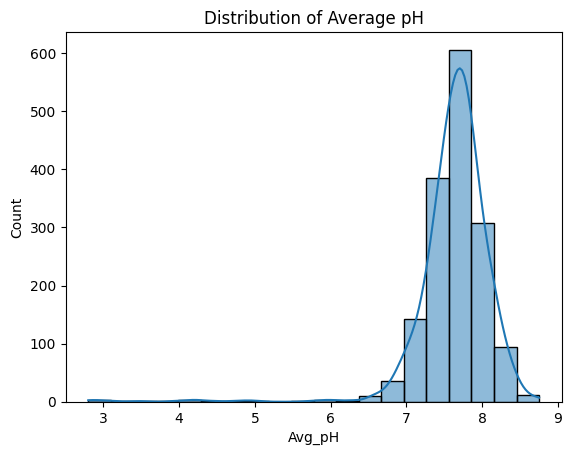

In [74]:
sns.histplot(df['Avg_pH'],bins=20, kde=True)
plt.title('Distribution of Average pH')

Visualization of distribution using a histogram, showing monthly variations in pH.


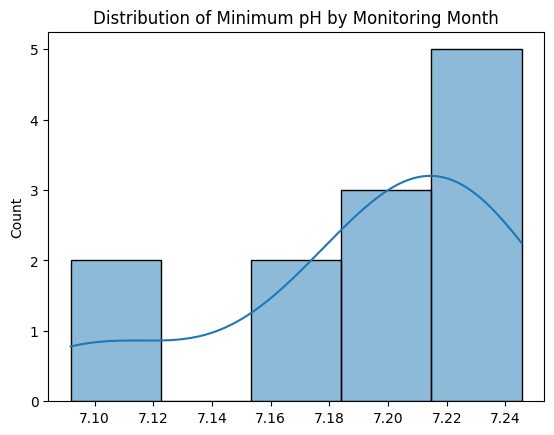

In [75]:
print("Visualization of distribution using a histogram, showing monthly variations in pH.")
dd=df.groupby('Monitoring_Month')['Min_pH'].mean()
sns.histplot(dd.values, kde=True)
plt.title("Distribution of Minimum pH by Monitoring Month")
plt.show()

**Top 10 States with Highest Average Water Temperature**

In [76]:
df.groupby('State')['Avg_Temp'].mean().sort_values(ascending=False).head(10)

State
Puducherry        32.000000
Tamil Nadu        28.408772
Gujarat           27.607955
Kerala            26.666667
Odisha            26.182000
West Bengal       26.137931
Tripura           25.900000
Karnataka         25.882273
Delhi             25.815669
Andhra Pradesh    25.109375
Name: Avg_Temp, dtype: float64

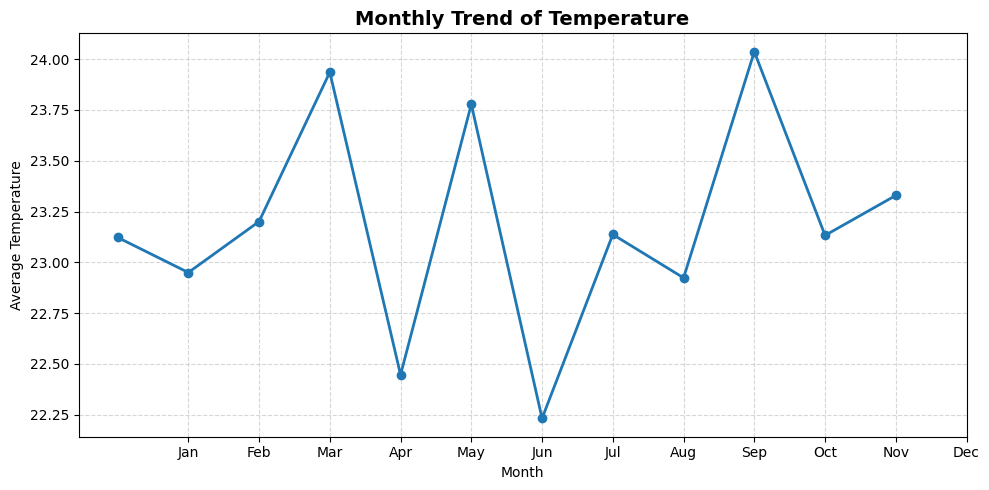

In [77]:
plt.figure(figsize=(10,5))
Month_Trend = df.groupby('Monitoring_Month')['Avg_Temp'].mean()

plt.plot( Month_Trend.index, Month_Trend.values, marker='o', linewidth=2)

plt.title("Monthly Trend of Temperature", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Average Temperature")

plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(ticks=range(1,13), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()

**This boxplot displays the distribution and variation of average water temperature**

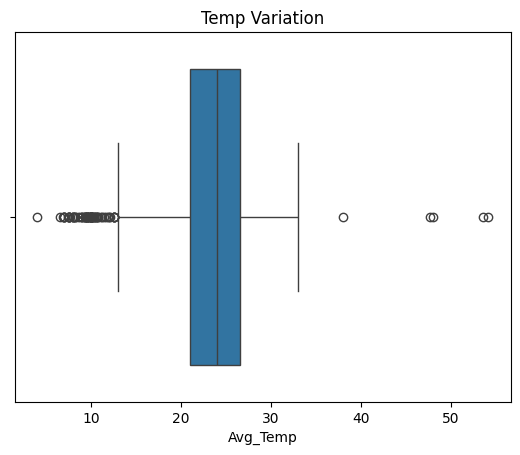

In [78]:
sns.boxplot(x=df['Avg_Temp'])
plt.title("Temp Variation")
plt.show()

**Classification of Water Quality Using Biological Oxygen Demand (BOD)**

In [79]:
def classify(row):
    if row['Avg_Dissolved_Oxygen'] >= 6 and row['Avg_BOD'] <= 3:
        return 'Good'
    elif row['Avg_Dissolved_Oxygen'] >= 4 and row['Avg_BOD'] <= 6:
        return 'Moderate'
    else:
        return 'Poor'

df['Water_Quality'] = df.apply(classify, axis=1)

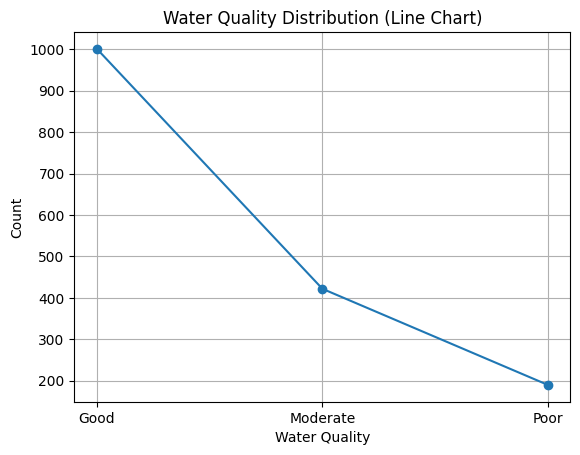

In [80]:
counts = df['Water_Quality'].value_counts().sort_index()

plt.figure()
plt.plot(counts.index, counts.values, marker='o')
plt.title("Water Quality Distribution (Line Chart)")
plt.xlabel("Water Quality")
plt.ylabel("Count")
plt.grid()

plt.show()

In [81]:
# Worst states
print(df.groupby('State')['Avg_BOD'].mean().sort_values(ascending=False).head())

# Worst rivers
print(df[df['Water_Quality']=="Poor"].groupby('River_Name').size().sort_values(ascending=False).head())

State
Delhi            23.877778
Uttar Pradesh    10.046821
Haryana           9.258249
Tamil Nadu        8.851295
Punjab            8.485330
Name: Avg_BOD, dtype: float64
River_Name
Yamuna    24
Hindon    12
Sutlej     8
Gomti      7
Cooum      7
dtype: int64


**Pollution Risk Score** - ***This score helps identify high-risk polluted water zones for monitoring.***

In [82]:
df['Pollution_Risk'] = (df['Max_Dissolved_Oxygen'] / (df['Max_Dissolved_Oxygen'] + 1)) * 100
df.head()

,Country,Year,State,Station_ID,River_Location,River_Name,Monitoring_Month,Min_Temp For River Water,Max_Temp For River Water,Min_Dissolved_Oxygen,...,Min_BOD,Max_BOD,Min_Nitrate (N) Required For River Water,Max_Nitrate (N) Required For River Water,Avg_Dissolved_Oxygen,Avg_BOD,Avg_pH,Avg_Temp,Water_Quality,Pollution_Risk
0,India,2023,Madhya Pradesh,4620,"RIVER AJAB BOURALI AT PETLAWAD DAM PETLAVAD, J...",Ajab,Oct,20.0,21.5,6.9,...,1.0,1.200000,0.72686,1.69,7.30,1.100000,7.90,20.75,Good,88.505747
1,India,2023,Tamil Nadu,3023,"RIVER VASISTA AT THULUKANNUR AT SALEM, D/S OF ...",Vasista,Aug,26.0,31.0,0.3,...,2.7,120.000000,0.32000,4.43,3.15,61.350000,7.45,28.50,Poor,85.714286
2,India,2023,Meghalaya,3368,RIVER NONBAH AT PHOTSOHSAT,Nonbah,Apr,13.6,20.0,6.6,...,1.1,5.836582,0.32000,0.54,7.60,3.468291,7.00,16.80,Moderate,89.583333
3,India,2023,Karnataka,3578,RIVER CAUVERY D/S OF MADDUR WATER SUPPLY TREAT...,Cauvery,Apr,19.0,27.0,6.5,...,1.0,3.000000,0.75000,2.40,6.90,2.000000,8.35,23.00,Good,87.951807
4,India,2023,Tripura,3419,"RIVER MANU AT KUMARGHAT, NORTH TRIPURA",Manu,Jan,21.0,31.0,5.3,...,1.2,1.900000,0.70000,1.70,5.85,1.550000,7.40,26.00,Moderate,86.486486


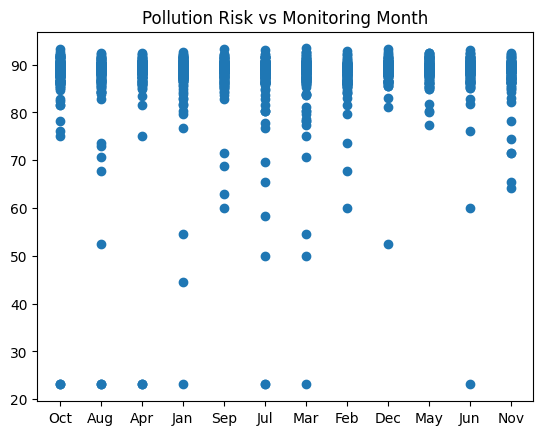

In [83]:
x = df['Pollution_Risk']
y = df['Monitoring_Month']
plt.scatter(y,x)
plt.title("Pollution Risk vs Monitoring Month")
plt.show()

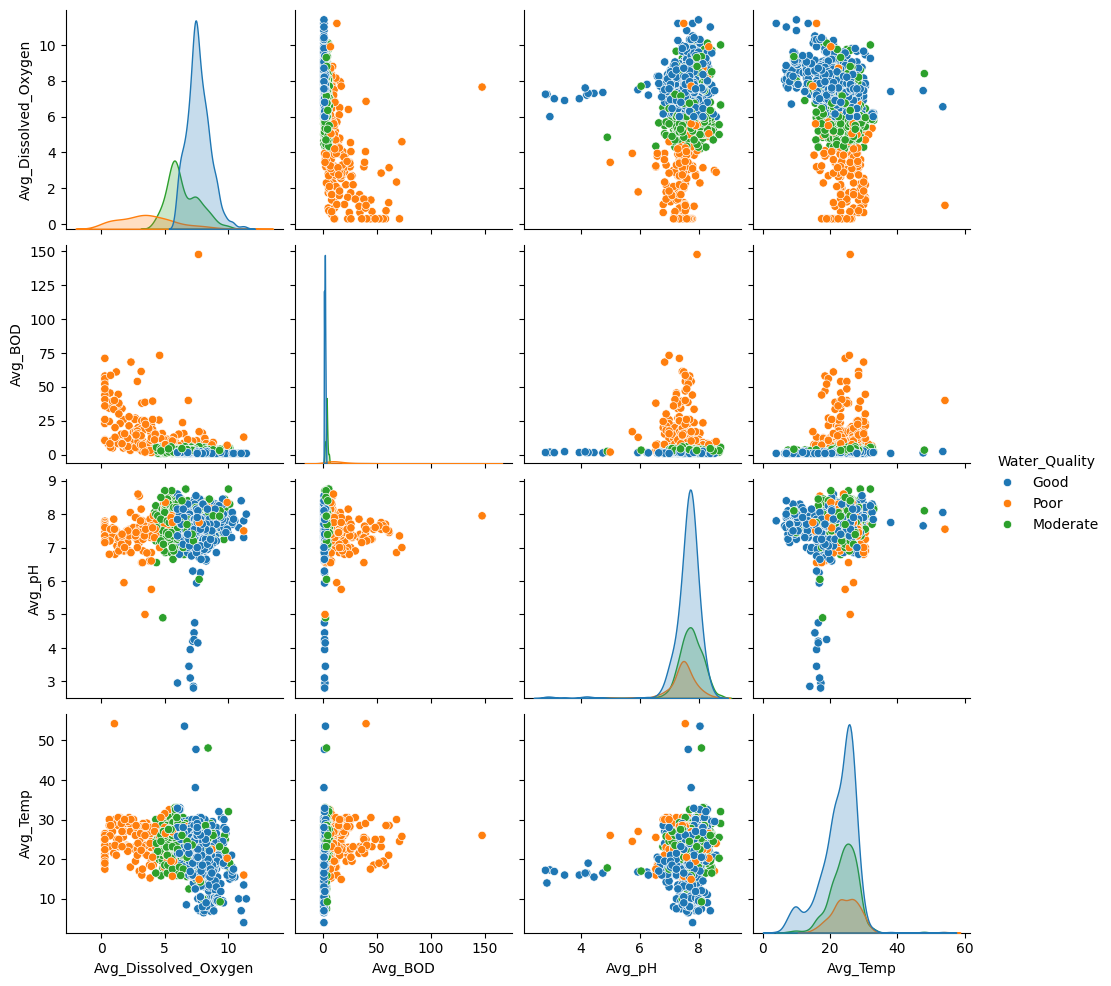

In [84]:
cols = ['Avg_Dissolved_Oxygen', 'Avg_BOD', 'Avg_pH', 'Avg_Temp']
sns.pairplot(df[cols + ['Water_Quality']], hue='Water_Quality')
plt.show()

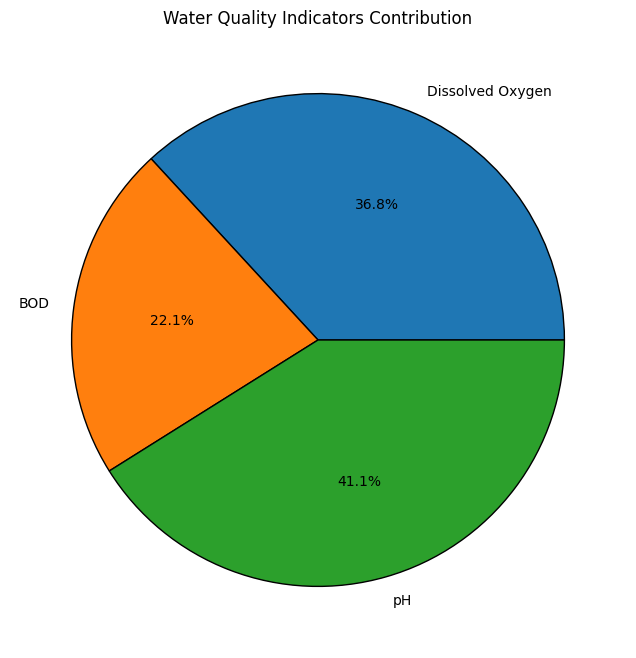

In [85]:
df['pollution_index'] = df['Avg_BOD'] / df['Avg_Dissolved_Oxygen']

sizes = [
    df['Avg_Dissolved_Oxygen'].mean(),
    df['Avg_BOD'].mean(),
    df['Avg_pH'].mean()
]

labels = ['Dissolved Oxygen', 'BOD', 'pH']
plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', wedgeprops={'edgecolor': 'black'})
plt.title("Water Quality Indicators Contribution")
plt.show()

### **Correlation Heatmap of Key Water Quality Parameters**

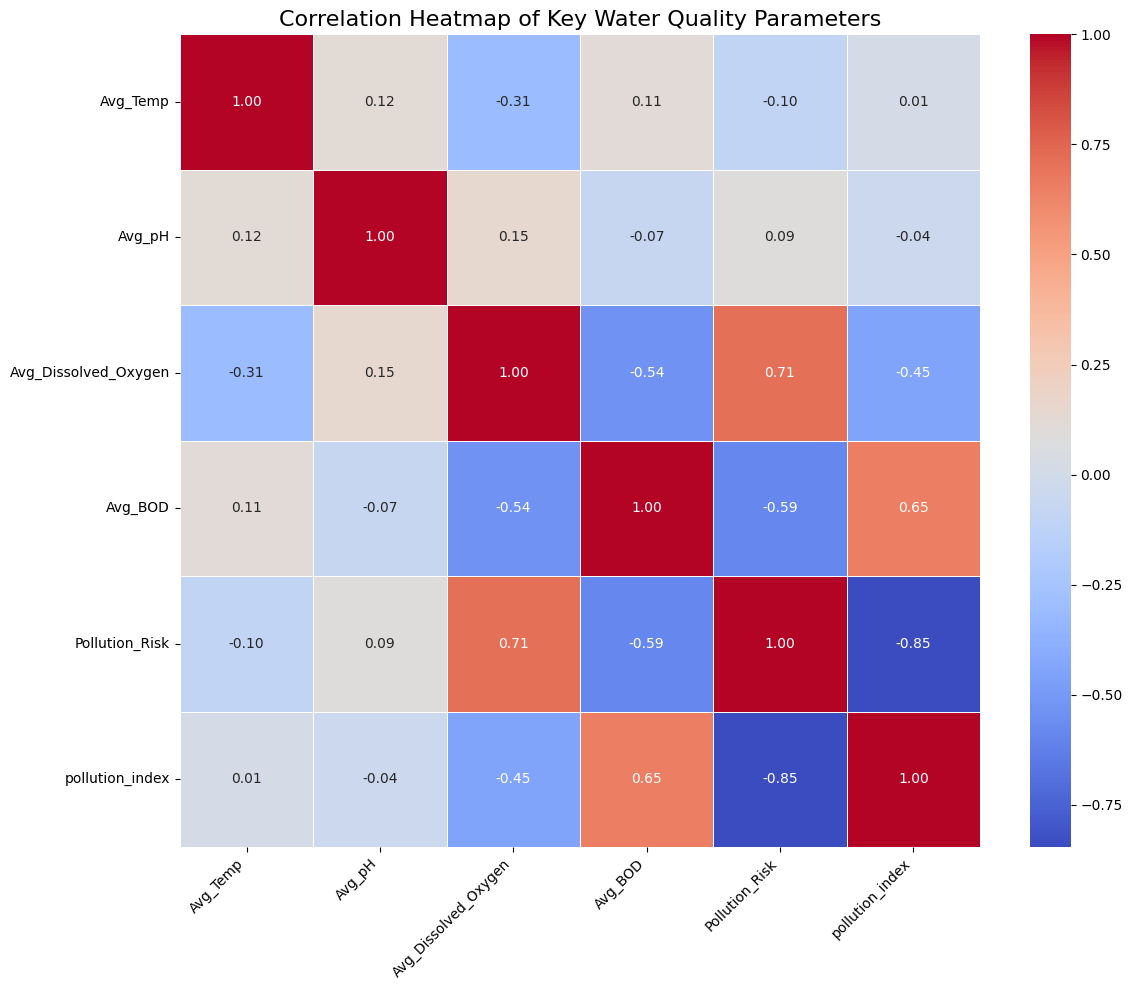

In [86]:
df['pollution_index'] = df['Avg_BOD'] / df['Avg_Dissolved_Oxygen']

plt.figure(figsize=(12, 10))
core_features = [
    'Avg_Temp',
    'Avg_pH',
    'Avg_Dissolved_Oxygen',
    'Avg_BOD',
    'Pollution_Risk',
    'pollution_index'
]
corr_matrix = df[core_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10}, linewidths=0.5)
plt.title('Correlation Heatmap of Key Water Quality Parameters', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [87]:
print(df.dtypes)

Country                                      object
Year                                          int64
State                                        object
Station_ID                                    int64
River_Location                               object
River_Name                                   object
Monitoring_Month                             object
Min_Temp For River Water                    float64
Max_Temp For River Water                    float64
Min_Dissolved_Oxygen                        float64
Max_Dissolved_Oxygen                        float64
Min_pH                                      float64
Max_pH                                      float64
Min_Conductivity_Level                      float64
Max_Conductivity_Level                      float64
Min_BOD                                     float64
Max_BOD                                     float64
Min_Nitrate (N) Required For River Water    float64
Max_Nitrate (N) Required For River Water    float64
Avg_Dissolve

### **Machine Learning: Water Quality Classification**
We will use a Random Forest Classifier to predict the `Water_Quality` ('Good', 'Moderate', 'Poor') based on features like Temperature, pH, Dissolved Oxygen, BOD, and Conductivity.

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. Feature Selection
# We avoid using 'Pollution_Risk' or 'Avg_BOD' directly if they were used to define the label to prevent data leakage,
# but here we'll use the primary measurement columns.
features = ['Avg_Temp', 'Avg_pH', 'Avg_Dissolved_Oxygen', 'Avg_BOD', 'Min_Conductivity_Level', 'Max_Conductivity_Level']
X = df[features]

# 2. Target Encoding
le = LabelEncoder()
y = le.fit_transform(df['Water_Quality'])

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Initialization & Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predictions
y_pred = rf_model.predict(X_test)

# 6. Evaluation
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy Score: 1.0

Classification Report:
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00       197
    Moderate       1.00      1.00      1.00        91
        Poor       1.00      1.00      1.00        35

    accuracy                           1.00       323
   macro avg       1.00      1.00      1.00       323
weighted avg       1.00      1.00      1.00       323



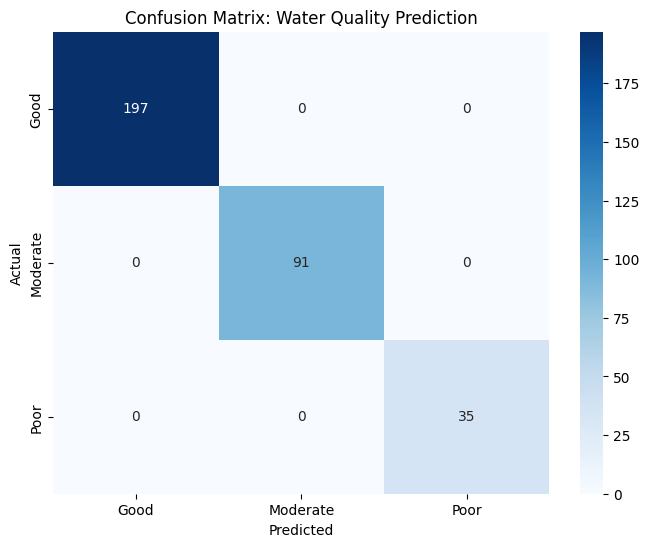

In [89]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Water Quality Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

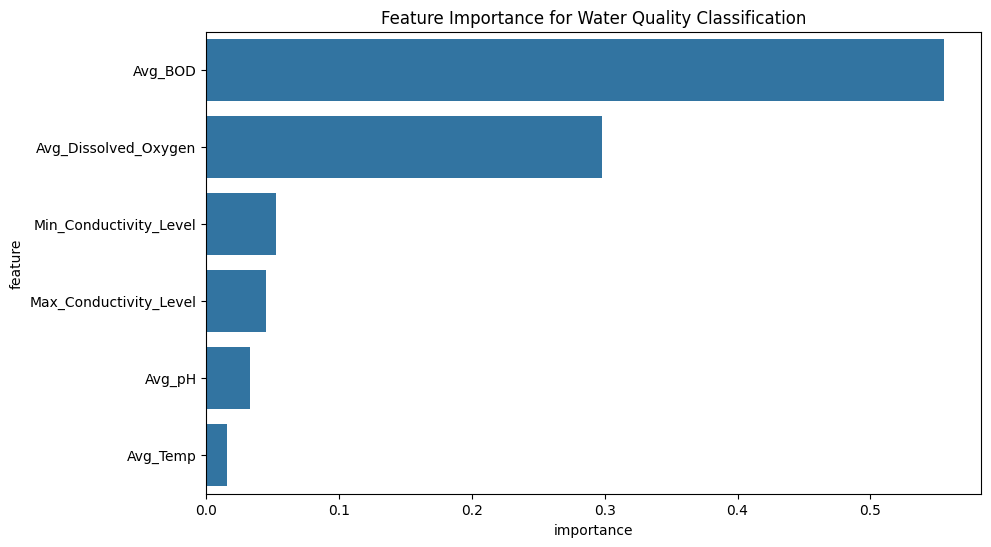

In [90]:
importances = pd.DataFrame({'feature': features, 'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importances)
plt.title('Feature Importance for Water Quality Classification')
plt.show()

### **Model Evaluation: Accuracy (Classification) and R2 Score (Regression)**
We already have the accuracy for our classification model. Now, we will also train a regressor for the `Pollution_Risk` and calculate the R2 score.

In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Classification Accuracy (from previous model)
print(f"Classification Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 2. Regression for Pollution_Risk
# Target is now the continuous Pollution_Risk column
y_reg = df['Pollution_Risk']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Initialize and train regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_reg, y_train_reg)

# Predict and calculate R2 Score
y_reg_pred = rf_regressor.predict(X_test_reg)
r2 = r2_score(y_test_reg, y_reg_pred)

print(f"Regression R2 Score (Pollution Risk): {r2:.4f}")

Classification Accuracy: 1.0000
Regression R2 Score (Pollution Risk): 0.9854
